<a href="https://colab.research.google.com/github/BenRyan-8/MarketingAnalytics_CA/blob/main/marketinganalyticsCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Sales Prediction — Walmart Weekly Sales Forecasting
### Marketing Analytics (MRKT 4109) - TU912/4

---

**Authors:**

Abdolhmed Bashara | C22406056

Alicia Seidou | C22495584

Ben Ryan | C22513316



---

This project applies machine learning techniques to forecast weekly retail sales across 45 Walmart stores, using historical sales data alongside economic indicators such as temperature, fuel price, CPI, and unemployment rate. The analysis covers exploratory data analysis, feature engineering, and the development and evaluation of multiple regression models including Linear Regression, Support Vector Regression, Neural Networks, Random Forest, XGBoost, LightGBM, and AdaBoost.

## 1. Data Loading & Initial Exploration

### 1.1 Data Overview
Loading in data and checking the structure, data types, and shape of the dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/BenRyan-8/MarketingAnalytics_CA/main/Walmart.csv"
df_walmart = pd.read_csv(url)
df_walmart.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
df_walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [3]:
df_walmart.shape

(6435, 8)

In [4]:
df_walmart.duplicated().sum()

np.int64(0)

### 1.2 Feature Distributions
Initial histograms to understand the distribution of each variable before any preprocessing.

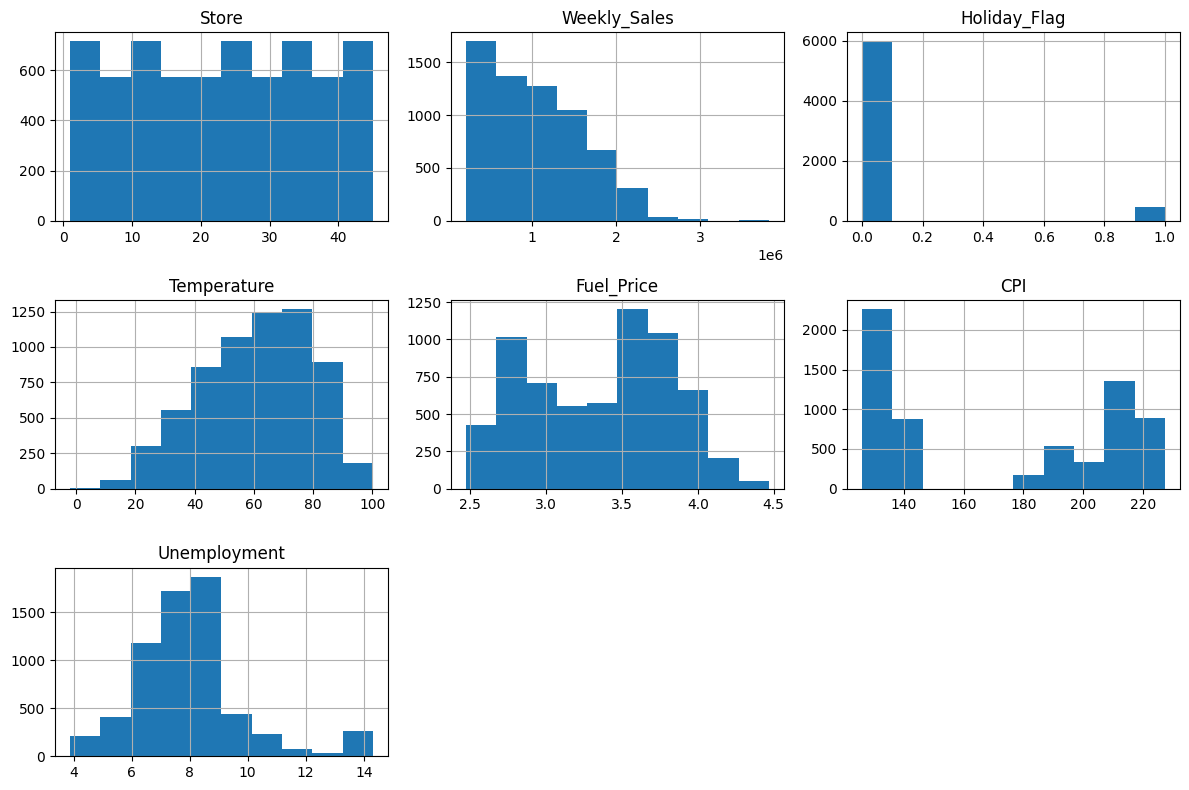

In [5]:
df_walmart.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

Sorting data by chronological order rather than by store

In [6]:
df_walmart['Date'] = pd.to_datetime(df_walmart['Date'],dayfirst=True)
df_walmart = df_walmart.sort_values(by = 'Date', ascending= True)

### 1.3 Dataframe Copies
Three separate dataframes are created from the cleaned data, one for EDA, one for tree-based models, and one for scaled models. This is to keep each pipeline independent.

In [7]:
df_eda = df_walmart.copy()
df_tree = df_walmart.copy()
df_scaled = df_walmart.copy()

In [90]:
df_eda['Year'] = df_eda['Date'].dt.year
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Week'] = df_eda['Date'].dt.isocalendar().week

In [9]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 534.2 KB


## 2. Exploratory Data Analysis (EDA)
The following section explores the dataset to understand the distribution of sales, identify seasonal patterns, and examine the relationship between weekly sales and other factors within the dataset.

### 2.1 Correlation Analysis
Examining the linear correlation between all numeric variables and Weekly Sales to identify which features have the strongest direct relationship with the target variable.

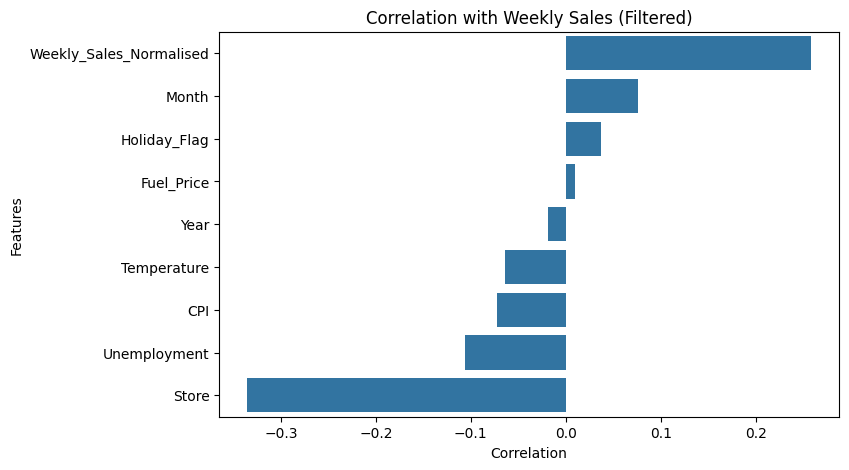

In [91]:
# Correlation of all numeric variables with Weekly_Sales

corr_with_sales = df_eda.corr(numeric_only=True)['Weekly_Sales'].sort_values(ascending=False)

#dropping
corr_filtered = corr_with_sales.drop(['Weekly_Sales', 'Week'])


plt.figure(figsize=(8,5))
sns.barplot(x=corr_filtered.values, y=corr_filtered.index)

plt.title("Correlation with Weekly Sales (Filtered)")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

### 2.2 Correlation Heatmap
A full correlation heatmap across all numeric features to identify any multicollinearity between predictors.

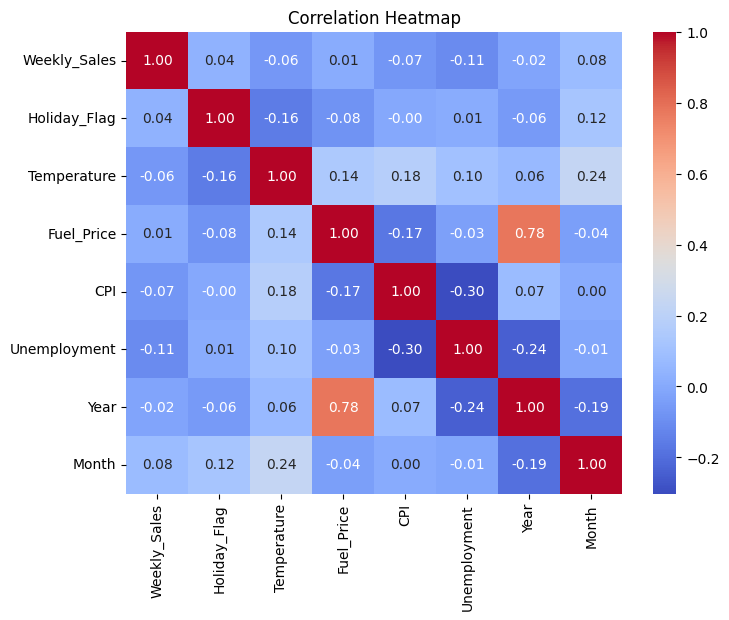

In [11]:
# Select only relevant columns (drop Store)
corr_matrix = df_eda.drop(columns=['Store','Week']).corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### 2.3 Feature Distributions
Distribution plots for the necessary features to check for skewness and outliers.

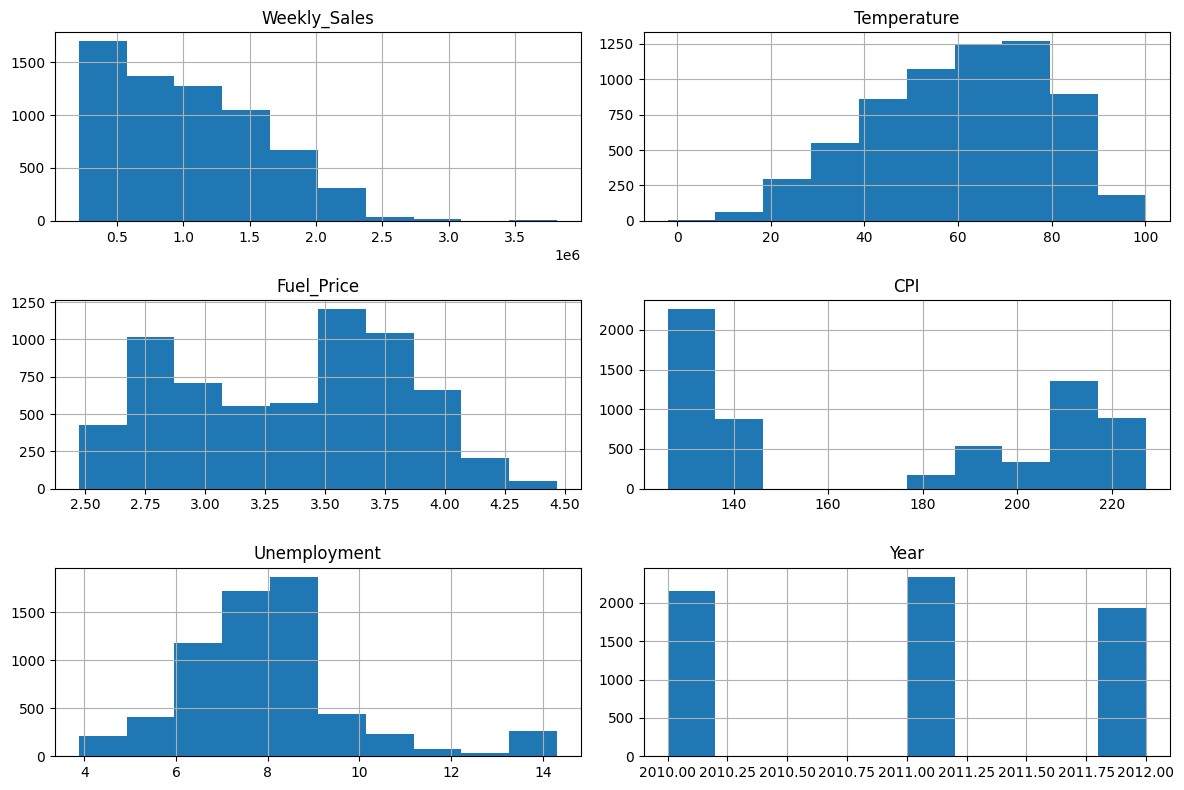

In [85]:
df_eda[['Weekly_Sales', 'Temperature','Fuel_Price', 'CPI', 'Unemployment','Year']].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

### 2.4 Average Weekly Sales by Store
Examining sales performance across all 45 stores to identify high and low performing stores. The large variance between stores suggests store identity is a key predictor of weekly sales.

In [13]:
# Average weekly sales per store
avg_sales_per_store = (
    df_eda.groupby('Store')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_per_store)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
19    1.444999e+06
31    1.395901e+06
23    1.389864e+06
24    1.356755e+06
11    1.356383e+06
28    1.323522e+06
41    1.268125e+06
32    1.166568e+06
18    1.084718e+06
22    1.028501e+06
12    1.009002e+06
26    1.002912e+06
34    9.667816e+05
40    9.641280e+05
35    9.197250e+05
8     9.087495e+05
17    8.935814e+05
45    7.859814e+05
21    7.560691e+05
25    7.067215e+05
43    6.333247e+05
15    6.233125e+05
7     5.706173e+05
42    5.564039e+05
9     5.439806e+05
29    5.394514e+05
16    5.192477e+05
37    5.189003e+05
30    4.385796e+05
3     4.027044e+05
38    3.857317e+05
36    3.735120e+05
5     3.180118e+05
44    3.027489e+05
33    2.598617e+05
Name: Weekly_Sales, dtype: float64


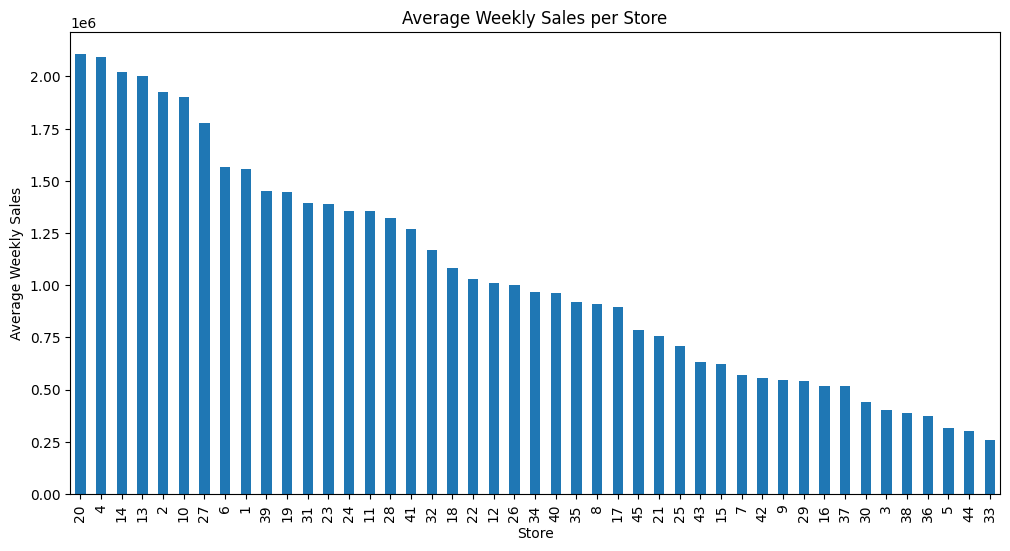

In [14]:
avg_sales_per_store.plot(kind='bar', figsize=(12,6))
plt.title('Average Weekly Sales per Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()

### 2.5 Best vs Worst Performing Stores
Isolating the top 2 and bottom 2 stores by average weekly sales for deeper comparison.

In [15]:
best_performers = avg_sales_per_store.head(2)
worst_performers = avg_sales_per_store.tail(2)

In [16]:
top_data = df_eda[df_eda['Store'].isin(best_performers.index)]
bottom_data = df_eda[df_eda['Store'].isin(worst_performers.index)]

####Best stores growth performance

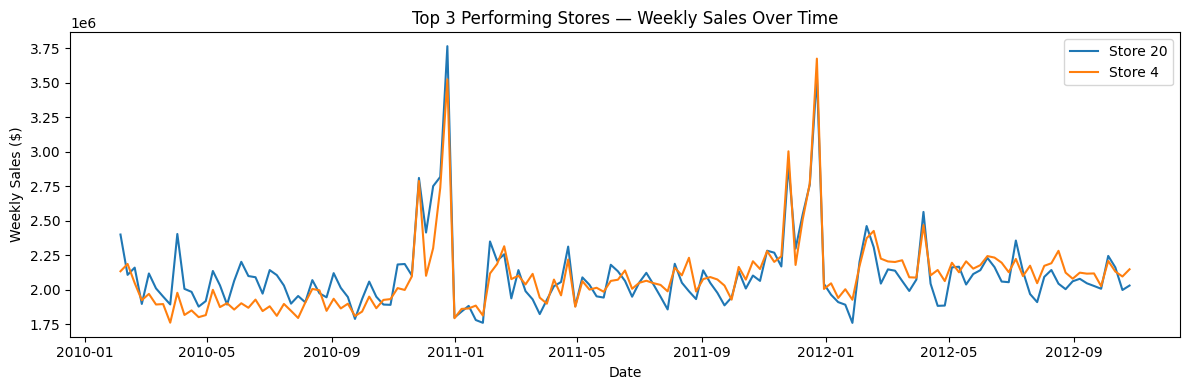

In [17]:
plt.figure(figsize=(12, 4))
for store in best_performers.index:
    store_data = top_data[top_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store}')
plt.title("Top 3 Performing Stores — Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

####Worst stores growth performance

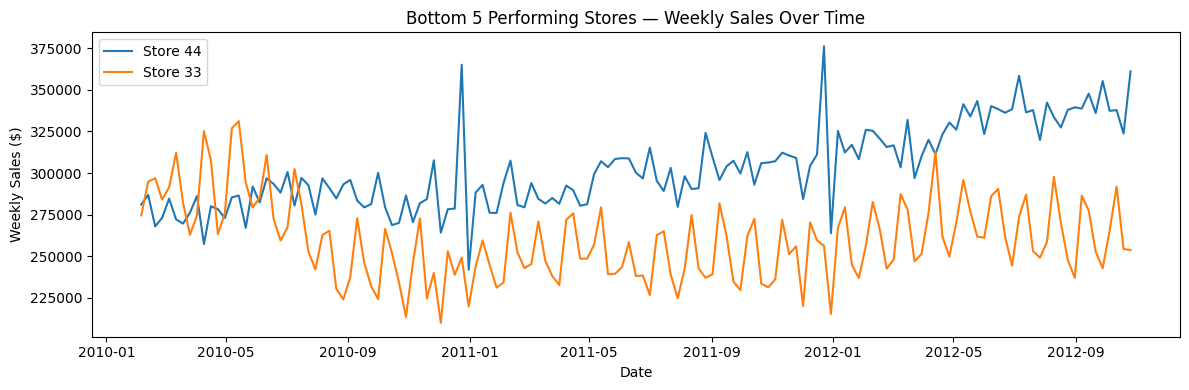

In [18]:
plt.figure(figsize=(12, 4))
for store in worst_performers.index:
    store_data = bottom_data[bottom_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store}')
plt.title("Bottom 5 Performing Stores — Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

### 2.6 Best vs Worst Stores — Combined View
Overlaying the top and bottom performing stores on a single chart to directly compare their sales trajectories. Top stores are shown with solid lines, bottom stores with dashed lines.

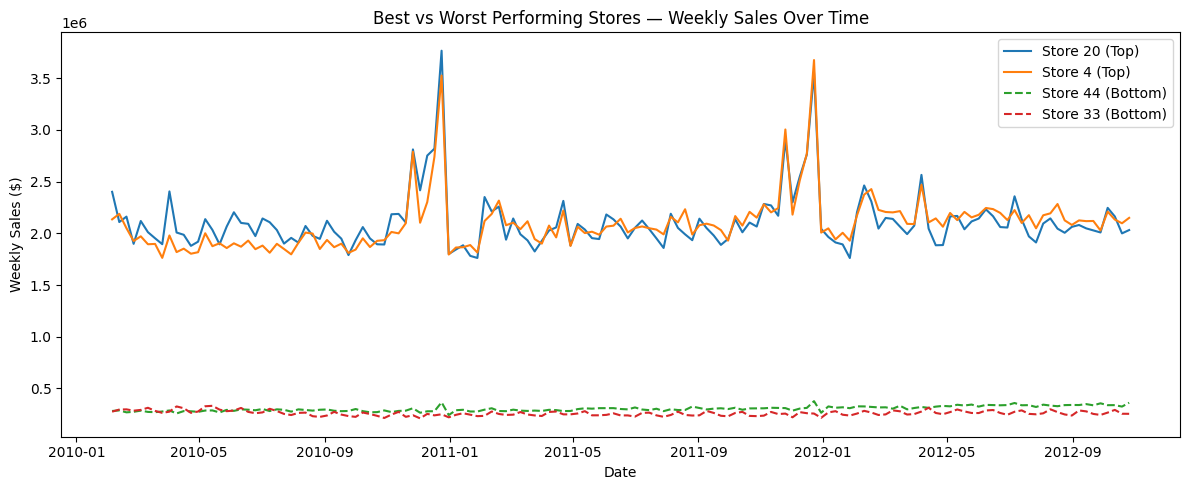

In [19]:
plt.figure(figsize=(12, 5))

for store in best_performers.index:
    store_data = top_data[top_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store} (Top)', linestyle='-')

for store in worst_performers.index:
    store_data = bottom_data[bottom_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store} (Bottom)', linestyle='--')

plt.title("Best vs Worst Performing Stores — Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

### 2.7 Normalised Sales Comparison
Dividing each store's weekly sales by its own mean to rescale all stores around 1.0. This removes the effect of store size and allows direct comparison of seasonal patterns and volatility across the top and bottom performing stores.

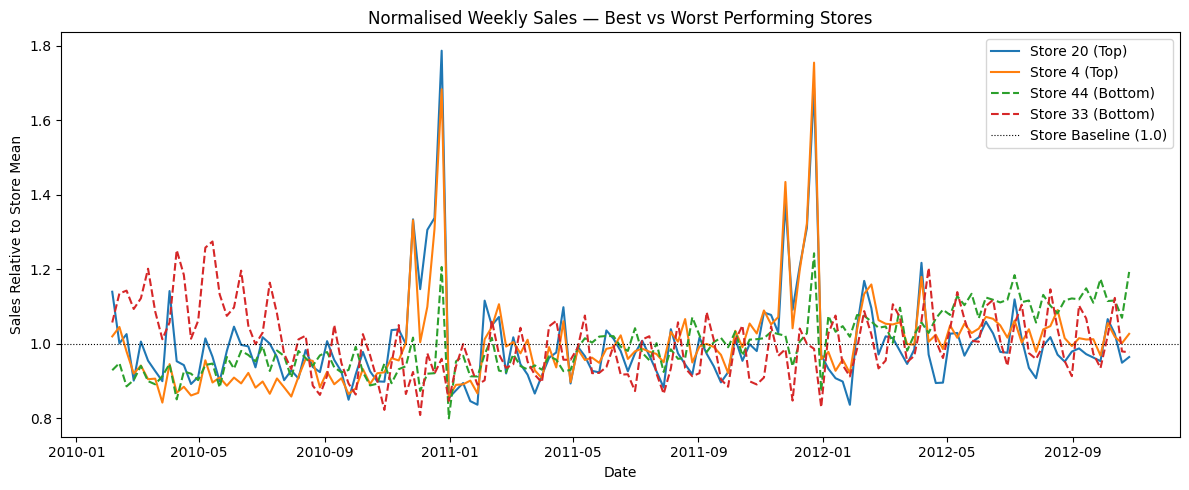

In [20]:
store_means_eda = df_eda.groupby('Store')['Weekly_Sales'].mean()
df_eda['Weekly_Sales_Normalised'] = df_eda['Weekly_Sales'] / df_eda['Store'].map(store_means_eda)

plt.figure(figsize=(12, 5))
for store in best_performers.index:
    store_data = df_eda[df_eda['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales_Normalised'],
             label=f'Store {store} (Top)', linestyle='-')
for store in worst_performers.index:
    store_data = df_eda[df_eda['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales_Normalised'],
             label=f'Store {store} (Bottom)', linestyle='--')
plt.axhline(1.0, color='black', linewidth=0.8, linestyle=':', label='Store Baseline (1.0)')
plt.title('Normalised Weekly Sales — Best vs Worst Performing Stores')
plt.xlabel('Date')
plt.ylabel('Sales Relative to Store Mean')
plt.legend()
plt.tight_layout()
plt.show()

### 2.8 Total Weekly Sales Over Time
Aggregating sales across all 45 stores to examine the overall sales trend and identify periods of peak and low demand across all of Walmart

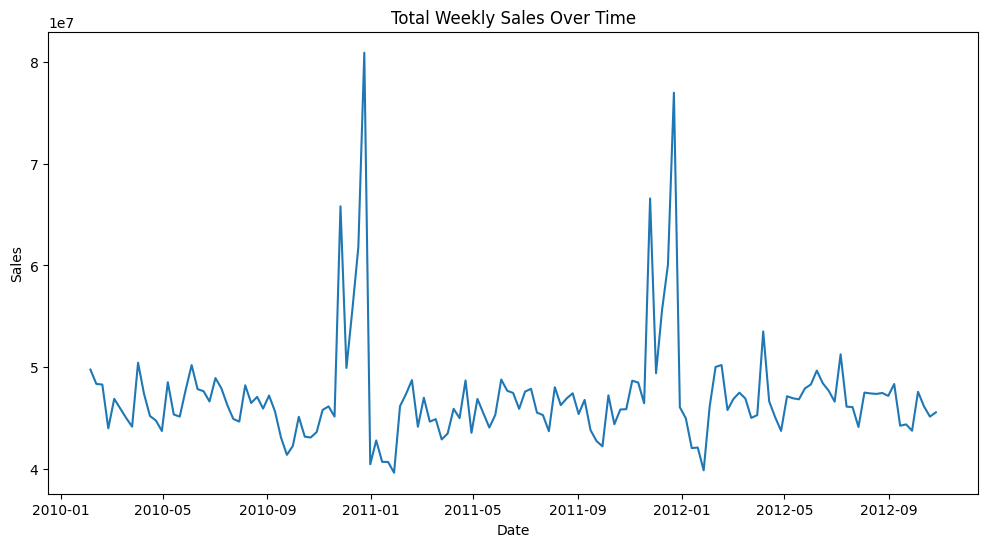

In [21]:
# Aggregate total sales per week
weekly_sales = df_eda.groupby('Date')['Weekly_Sales'].sum()


plt.figure(figsize=(12,6))
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### 2.9 Holiday Impact on Sales
Comparing average weekly sales on holiday weeks versus non-holiday weeks. A positive lift on holiday weeks would suggest promotional or seasonal demand effects.

In [22]:
holidays = df_eda['Holiday_Flag'].value_counts(normalize=True) * 100
holidays

,proportion
Holiday_Flag,
0,93.006993
1,6.993007


In [23]:
holiday_sales = df_eda.groupby('Holiday_Flag')['Weekly_Sales'].mean()

holiday_sales

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


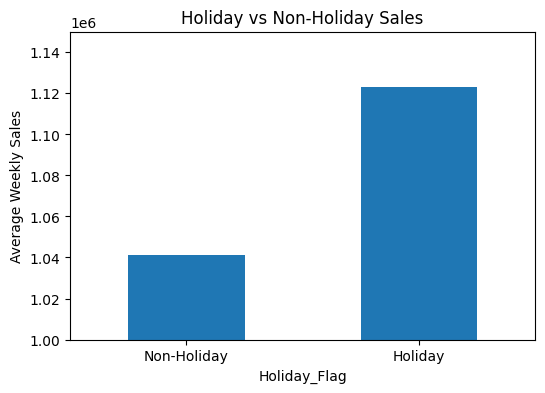

In [24]:
holiday_sales.plot(kind='bar', figsize=(6,4))
plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("Average Weekly Sales")
plt.xticks([0,1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.ylim(1000000, 1150000)
plt.show()

### 2.10 Holiday Impact — Top vs Bottom Stores
Examining whether the holiday sales lift differs between high and low performing stores.

**“Do strong stores benefit more from holidays than weak ones?”**

More of a significant difference between holidays and not holiday of top stores than weak stores.

In [25]:
top_holiday = top_data.groupby('Holiday_Flag')['Weekly_Sales'].mean()
bottom_holiday = bottom_data.groupby('Holiday_Flag')['Weekly_Sales'].mean()

print("Top Stores:\n", top_holiday)
print("\nBottom Stores:\n", bottom_holiday)

Top Stores:
 Holiday_Flag
0    2.090302e+06
1    2.246069e+06
Name: Weekly_Sales, dtype: float64

Bottom Stores:
 Holiday_Flag
0    281454.919549
1    279315.060000
Name: Weekly_Sales, dtype: float64


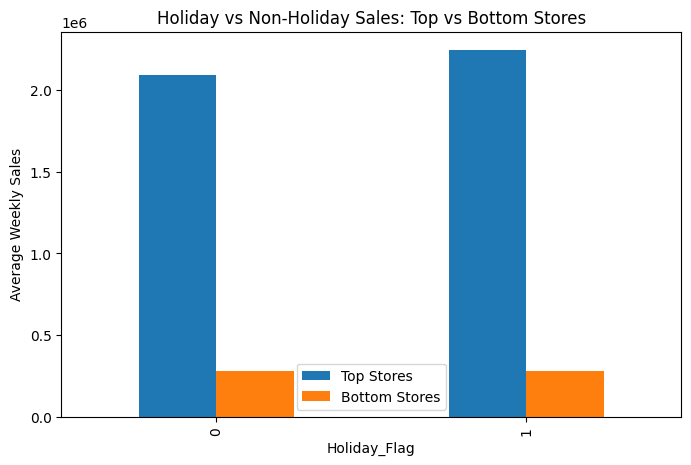

In [26]:
comparison = pd.DataFrame({
    'Top Stores': top_holiday,
    'Bottom Stores': bottom_holiday
})

comparison.plot(kind='bar', figsize=(8,5))
plt.title("Holiday vs Non-Holiday Sales: Top vs Bottom Stores")
plt.ylabel("Average Weekly Sales")
plt.show()

### 2.13 Seasonality — Weekly Sales Pattern
Plotting average sales by week of year to identify recurring seasonal peaks, such as holiday periods at the end of the year.

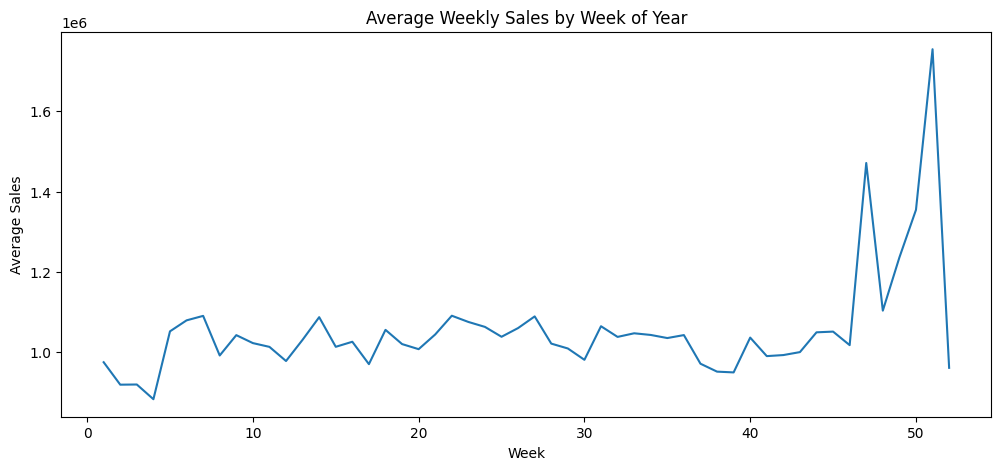

In [27]:
weekly_pattern = df_eda.groupby('Week')['Weekly_Sales'].mean()

weekly_pattern.plot(figsize=(12,5))
plt.title('Average Weekly Sales by Week of Year')
plt.xlabel('Week')
plt.ylabel('Average Sales')
plt.show()

December is the best performing month. Week 45 to 52 the best performing weeks

### 2.14 Sales by Temperature Range
Binning temperature into ranges and examining average sales per bin to determine whether weather conditions influence consumer spending.

/tmp/ipykernel_8583/3255650556.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_sales = df_eda.groupby('Temp_Bin')['Weekly_Sales'].mean()


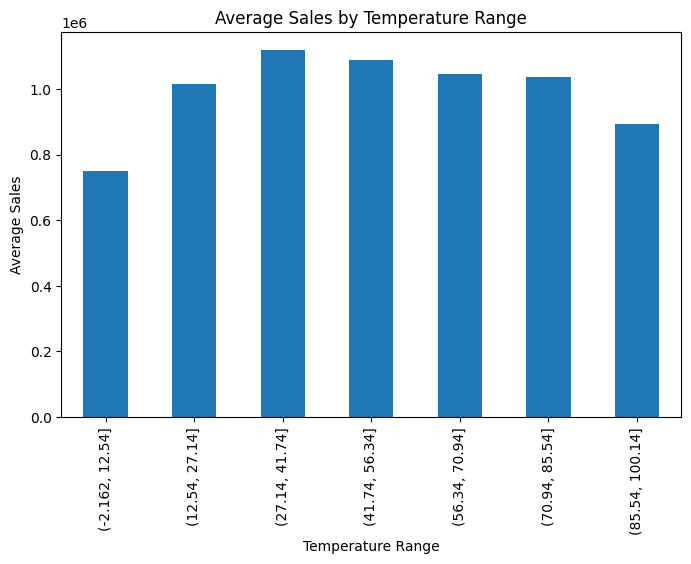

In [28]:
df_eda['Temp_Bin'] = pd.cut(df_eda['Temperature'], bins=7)

temp_sales = df_eda.groupby('Temp_Bin')['Weekly_Sales'].mean()

temp_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average Sales")

plt.show()

Lower Sales at Extremes

Very cold (0-12°F) -> lower sales

Very hot (85-100°F) -> lower sales

Highest sales at moderate temperatures

### 2.15 Sales by Fuel Price Range
Examining whether higher fuel prices have a negative relationship with weekly sales.

/tmp/ipykernel_8583/4201200382.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fuel_sales = df_eda.groupby('Fuel_Bin')['Weekly_Sales'].mean()


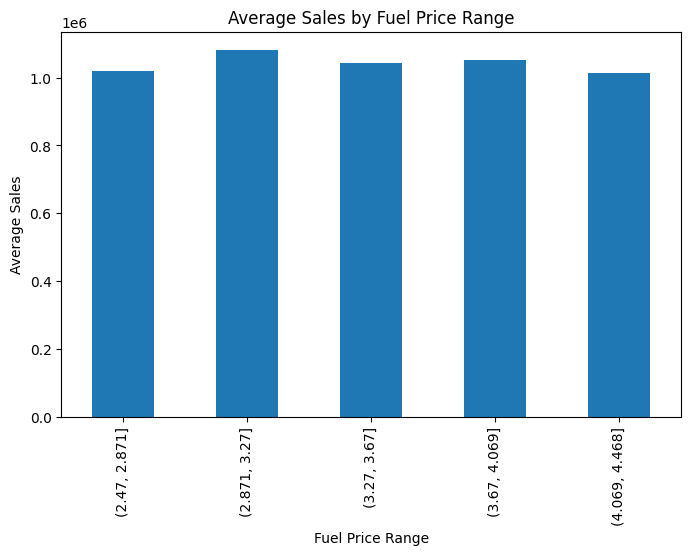

In [29]:
df_eda['Fuel_Bin'] = pd.cut(df_eda['Fuel_Price'], bins=5)

fuel_sales = df_eda.groupby('Fuel_Bin')['Weekly_Sales'].mean()

fuel_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Fuel Price Range")
plt.xlabel("Fuel Price Range")
plt.ylabel("Average Sales")

plt.show()

Fuel price shows minimal relationship with weekly sales, suggesting that short-term fluctuations in fuel costs do not significantly influence retail purchasing behaviour in this dataset

### 2.16 Sales by Unemployment Rate
Higher unemployment typically reduces consumer spending. This section examines whether that relationship is visible in the data.

/tmp/ipykernel_8583/640463970.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unemp_sales = df_eda.groupby('Unemp_Bin')['Weekly_Sales'].mean()


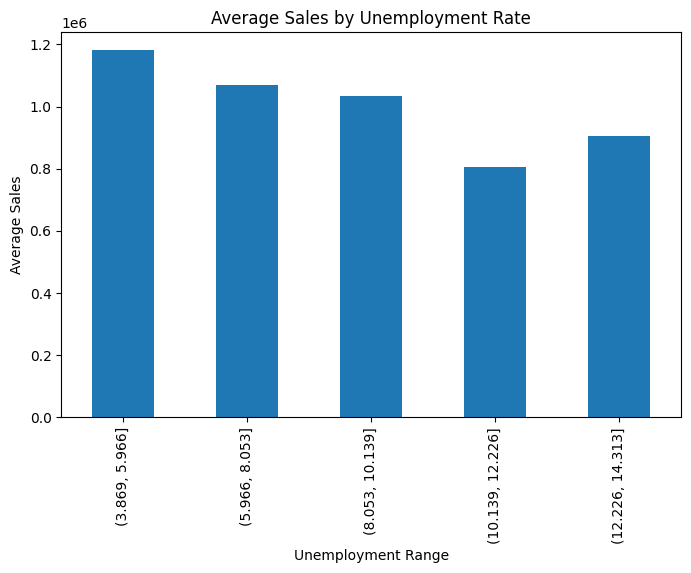

In [30]:
df_eda['Unemp_Bin'] = pd.cut(df_eda['Unemployment'], bins=5)

unemp_sales = df_eda.groupby('Unemp_Bin')['Weekly_Sales'].mean()

unemp_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Unemployment Rate")
plt.xlabel("Unemployment Range")
plt.ylabel("Average Sales")

plt.show()

## 3. Data Preprocessing — Tree-Based Models (Random Forest, XGBoost, LightGBM, AdaBoost)
Tree-based models do not require feature scaling or log transformation of the target variable. A separate preprocessing pipeline is applied to df_tree to prepare it for these modelss.

### 3.1 Date Feature Extraction and Cyclical Encoding
Year, month, and week number are extracted from the Date column to provide temporal context to the models and month and week are encoded using Sine and Cosine transformations.

In [31]:
df_tree['Date'] = pd.to_datetime(df_tree['Date'],dayfirst=True)

df_tree['Year'] = df_tree['Date'].dt.year
df_tree['Month'] = df_tree['Date'].dt.month
df_tree['Week'] = df_tree['Date'].dt.isocalendar().week

In [32]:
df_tree['Month_sin'] = np.sin(2 * np.pi * df_tree['Month'] / 12)
df_tree['Month_cos'] = np.cos(2 * np.pi * df_tree['Month'] / 12)

df_tree['Week_sin'] = np.sin(2 * np.pi * df_tree['Week'] / 52)
df_tree['Week_cos'] = np.cos(2 * np.pi * df_tree['Week'] / 52)

### 3.2 Feature Engineering: Store Mean Sales & Lag Features
Three categories of features were added to better capture the weekly sales patterns.

- **Store_Mean_Sales** : the average weekly sales per store, calculated from the training period only to prevent data leakage
- **Sales_Lag_1 / Lag_4 / Lag_52** : sales from 1 week ago, 4 weeks ago, and the same week in the prior year, this captures current short-term sales and seasonality from last year
- **Sales_Rolling_4** : a 4 week rolling average to smooth short-term noise in case the previous week was an outlier

In [33]:
# Store_Mean_Sales
split_idx_temp = int(len(df_tree) * 0.8)
store_mean_map = df_tree.iloc[:split_idx_temp].groupby('Store')['Weekly_Sales'].mean()
df_tree['Store_Mean_Sales'] = df_tree['Store'].map(store_mean_map)

# Lag features
df_tree = df_tree.sort_values(['Store', 'Date'])
df_tree['Sales_Lag_1']  = df_tree.groupby('Store')['Weekly_Sales'].shift(1)
df_tree['Sales_Lag_4']  = df_tree.groupby('Store')['Weekly_Sales'].shift(4)
df_tree['Sales_Lag_52'] = df_tree.groupby('Store')['Weekly_Sales'].shift(52)

# Rolling mean over last 4 weeks
df_tree['Sales_Rolling_4'] = (
    df_tree.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(4).mean())  )

df_tree.dropna(inplace=True)
df_tree = df_tree.sort_values('Date').reset_index(drop=True)
print('df_tree shape after lag features:', df_tree.shape)

df_tree shape after lag features: (4095, 20)


In [34]:
df_tree.drop(['Month', 'Week', 'Date'], axis=1, inplace=True)

In [35]:
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4095 entries, 0 to 4094
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Store             4095 non-null   int64  
 1   Weekly_Sales      4095 non-null   float64
 2   Holiday_Flag      4095 non-null   int64  
 3   Temperature       4095 non-null   float64
 4   Fuel_Price        4095 non-null   float64
 5   CPI               4095 non-null   float64
 6   Unemployment      4095 non-null   float64
 7   Year              4095 non-null   int32  
 8   Month_sin         4095 non-null   float64
 9   Month_cos         4095 non-null   float64
 10  Week_sin          4095 non-null   Float64
 11  Week_cos          4095 non-null   Float64
 12  Store_Mean_Sales  4095 non-null   float64
 13  Sales_Lag_1       4095 non-null   float64
 14  Sales_Lag_4       4095 non-null   float64
 15  Sales_Lag_52      4095 non-null   float64
 16  Sales_Rolling_4   4095 non-null   float64


In [36]:
# Keep Store as category for display but Holiday_Flag as int for XGBoost compatibility
df_tree['Store'] = df_tree['Store'].astype(int)
df_tree['Holiday_Flag'] = df_tree['Holiday_Flag'].astype(int)

### 3.3 Cyclical Encoding Visualisation

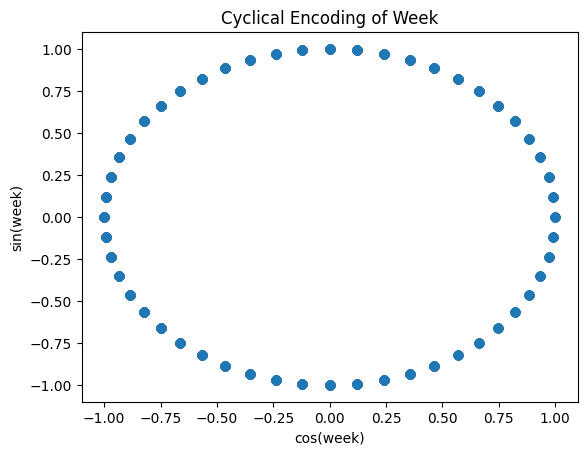

In [92]:
plt.figure()
plt.scatter(df_tree['Week_cos'], df_tree['Week_sin'])
plt.xlabel('cos(week)')
plt.ylabel('sin(week)')
plt.title('Cyclical Encoding of Week')
plt.show()

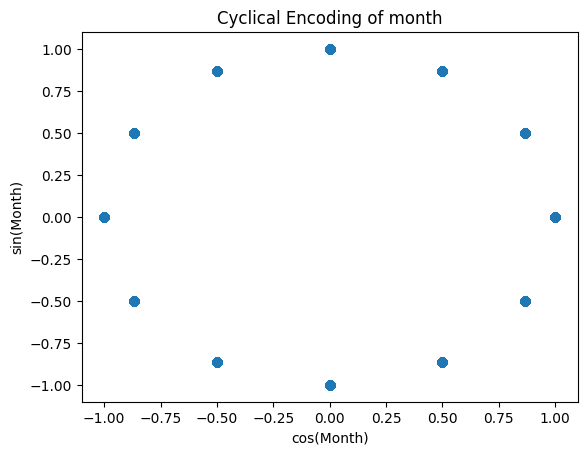

In [38]:
plt.figure()
plt.scatter(df_tree['Month_cos'], df_tree['Month_sin'])
plt.xlabel('cos(Month)')
plt.ylabel('sin(Month)')
plt.title('Cyclical Encoding of month')
plt.show()

### 3.4 One-Hot Encoding of Store and Year
Store and Year are one-hot encoded to convert them into numeric features

In [39]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_tree[['Store', 'Year']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store', 'Year'])
)

df_tree= pd.concat([df_tree.drop(['Store', 'Year'], axis=1), encoded_df], axis=1)

## 4. Data Preprocessing — Linear Regression, SVR & Neural Network
Unlike tree-based models, distance and gradient based models are sensitive to the scale and distribution of input features. We add log transformation to the target variable and standard scaling to all numeric features

### 4.1 Log Transformation and Standard scaling
Weekly sales has a right skew so log transformation is applied to make it closer to a normal distribution

Then all numeric features are standardised to have a mean of 0. sales_scaler is also kept so that the weekly sales can be transformed back to an interpretable value later on.

In [40]:
df_scaled['Weekly_Sales'] = np.log1p(df_scaled['Weekly_Sales'])

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# A dedicated scaler kept just for the target so we can inverse transform later
sales_scaler = StandardScaler()

df_scaled['Weekly_Sales_scaled']  = sales_scaler.fit_transform(df_scaled[['Weekly_Sales']])
df_scaled['Temperature_scaled']   = scaler.fit_transform(df_scaled[['Temperature']])
df_scaled['Fuel_Price_scaled']    = scaler.fit_transform(df_scaled[['Fuel_Price']])
df_scaled['CPI_scaled']           = scaler.fit_transform(df_scaled[['CPI']])
df_scaled['Unemployment_scaled']  = scaler.fit_transform(df_scaled[['Unemployment']])

### 4.2 Feature Distributions After Scaling
Histograms of all scaled features to confirm the transformations have been applied correctly

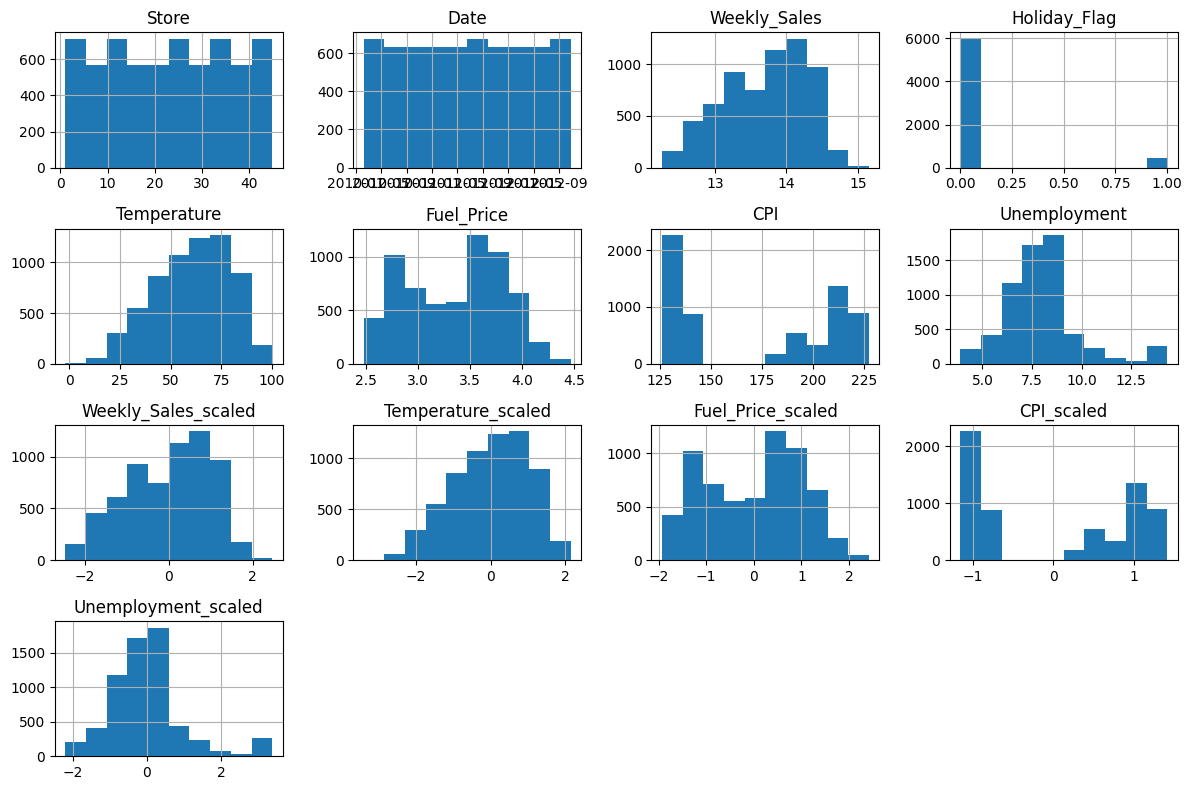

In [42]:
df_scaled.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

### 4.3 Date Feature Extraction & Cyclical Encoding
Extracting year, month and week. Month and week are then cyclically encoded using sine and cosine transformations similar to the tree-based preprocessing pipeline.

In [43]:
df_scaled['Date'] = pd.to_datetime(df_scaled['Date'],dayfirst=True)

df_scaled['Year'] = df_scaled['Date'].dt.year
df_scaled['Month'] = df_scaled['Date'].dt.month
df_scaled['Week'] = df_scaled['Date'].dt.isocalendar().week

In [44]:
df_scaled['Month_sin'] = np.sin(2 * np.pi * df_scaled['Month'] / 12)
df_scaled['Month_cos'] = np.cos(2 * np.pi * df_scaled['Month'] / 12)

df_scaled['Week_sin'] = np.sin(2 * np.pi * df_scaled['Week'] / 52)
df_scaled['Week_cos'] = np.cos(2 * np.pi * df_scaled['Week'] / 52)

### 4.4 Store Mean Sales & Lag Features
The same store-level and lag features applied to df_tree are added here to ensure both model families benefit from the same predictive signals.

In [45]:
# Store_Mean_Sales
split_idx_temp_s = int(len(df_scaled) * 0.8)
store_mean_map_s = df_scaled.iloc[:split_idx_temp_s].groupby('Store')['Weekly_Sales'].mean()
df_scaled['Store_Mean_Sales'] = df_scaled['Store'].map(store_mean_map_s)
df_scaled['Store_Mean_Sales_scaled'] = scaler.fit_transform(df_scaled[['Store_Mean_Sales']])
df_scaled.drop(columns=['Store_Mean_Sales'], inplace=True)

# Adding lags
df_scaled = df_scaled.sort_values(['Store', 'Date'])
df_scaled['Sales_Lag_1']  = df_scaled.groupby('Store')['Weekly_Sales'].shift(1)
df_scaled['Sales_Lag_4']  = df_scaled.groupby('Store')['Weekly_Sales'].shift(4)
df_scaled['Sales_Lag_52'] = df_scaled.groupby('Store')['Weekly_Sales'].shift(52)
df_scaled['Sales_Rolling_4'] = (
    df_scaled.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)
df_scaled.dropna(inplace=True)
df_scaled = df_scaled.sort_values('Date').reset_index(drop=True)

# Scale the lag and rolling features
df_scaled['Sales_Lag_1_scaled']     = scaler.fit_transform(df_scaled[['Sales_Lag_1']])
df_scaled['Sales_Lag_4_scaled']     = scaler.fit_transform(df_scaled[['Sales_Lag_4']])
df_scaled['Sales_Lag_52_scaled']    = scaler.fit_transform(df_scaled[['Sales_Lag_52']])
df_scaled['Sales_Rolling_4_scaled'] = scaler.fit_transform(df_scaled[['Sales_Rolling_4']])
df_scaled.drop(columns=['Sales_Lag_1','Sales_Lag_4','Sales_Lag_52','Sales_Rolling_4'], inplace=True)
print('df_scaled shape after lag features:', df_scaled.shape)

df_scaled shape after lag features: (4095, 25)


In [46]:
df_scaled.drop(['Date','Month','Week','Weekly_Sales','Temperature','Fuel_Price','Unemployment'], axis=1, inplace=True)

In [47]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4095 entries, 0 to 4094
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Store                    4095 non-null   int64  
 1   Holiday_Flag             4095 non-null   int64  
 2   CPI                      4095 non-null   float64
 3   Weekly_Sales_scaled      4095 non-null   float64
 4   Temperature_scaled       4095 non-null   float64
 5   Fuel_Price_scaled        4095 non-null   float64
 6   CPI_scaled               4095 non-null   float64
 7   Unemployment_scaled      4095 non-null   float64
 8   Year                     4095 non-null   int32  
 9   Month_sin                4095 non-null   float64
 10  Month_cos                4095 non-null   float64
 11  Week_sin                 4095 non-null   Float64
 12  Week_cos                 4095 non-null   Float64
 13  Store_Mean_Sales_scaled  4095 non-null   float64
 14  Sales_Lag_1_scaled      

In [48]:
df_scaled.head(1)

,Store,Holiday_Flag,CPI,Weekly_Sales_scaled,Temperature_scaled,Fuel_Price_scaled,CPI_scaled,Unemployment_scaled,Year,Month_sin,Month_cos,Week_sin,Week_cos,Store_Mean_Sales_scaled,Sales_Lag_1_scaled,Sales_Lag_4_scaled,Sales_Lag_52_scaled,Sales_Rolling_4_scaled
0,1,0,212.566881,0.999124,-0.997304,-0.805272,1.041542,-0.137093,2011,0.866025,0.5,0.568065,0.822984,0.947201,0.665084,0.829891,1.05681,0.740391


### 4.5 One-Hot Encoding of Store and Year
Store and Year are one-hot encoded to avoid multicollinearity

In [49]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_scaled[['Store', 'Year']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store', 'Year'])
)

df_scaled= pd.concat([df_scaled.drop(['Store', 'Year'], axis=1), encoded_df], axis=1)

## 5. Baseline Models
All models are trained on the first 80% of data chronologically and tested on the final 20% to prevent data leakage

In [50]:
# Features and target
X = df_tree.drop('Weekly_Sales', axis=1)
y = df_tree['Weekly_Sales']

# Split index (80%)
split_index = int(len(df_tree) * 0.8)

# Train = first 80%, Test = last 20%
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(X_train.shape, X_test.shape)

(3276, 59) (819, 59)


### 5.1 XGBoost Baseline

In [51]:
from xgboost import XGBRegressor

xgmodel = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1,
    enable_categorical = True
)

xgmodel.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = xgmodel.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)


MAE: 42010.7713270757
RMSE: 66226.25147342798
R2: 0.9843906513183156


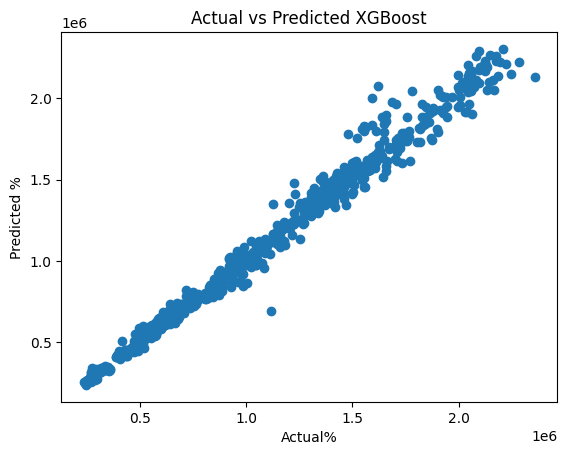

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted XGBoost")
plt.show()

### 5.2 LightGBM Baseline

In [54]:
!pip install lightgbm

import lightgbm as lgb

In [55]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=7,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    min_data_in_leaf=20
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, 

LGBMRegressor(bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
              learning_rate=0.05, max_depth=7, min_data_in_leaf=20,
              n_estimators=500)

In [56]:
y_pred = model_lgb.predict(X_test)

lgb_mae = mean_absolute_error(y_test, y_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lgb_r2 = r2_score(y_test, y_pred)

print("MAE:", lgb_mae)
print("RMSE:", lgb_rmse)
print("R2:", lgb_r2)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
MAE: 40352.20841764345
RMSE: 61188.70026539198
R2: 0.9866750100311208


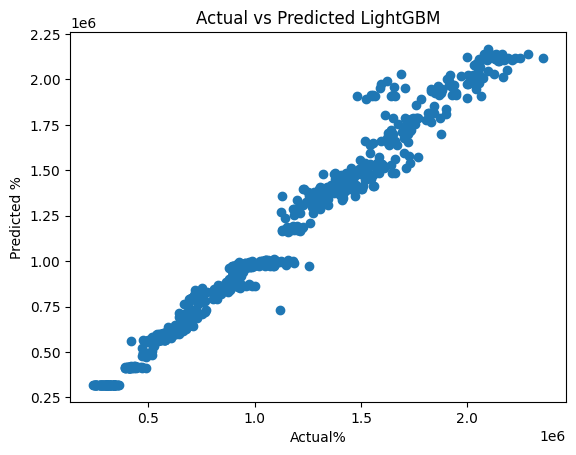

In [94]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted LightGBM")
plt.show()

### 5.3 Random Forest Baseline

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=600, n_jobs=-1,
                      random_state=42)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 40686.12925613762
RMSE: 59375.148457959905
R2: 0.9874531746920074


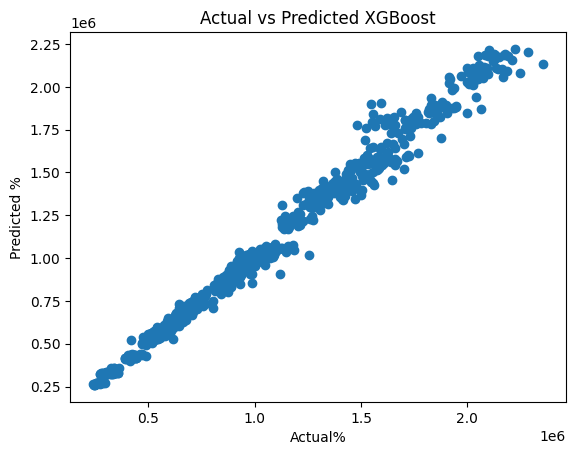

In [60]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted Random Forest")
plt.show()

### 5.4 AdaBoost Baseline

In [61]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Base learner for AdaBoost
base_model = DecisionTreeRegressor(max_depth=4, random_state=42)

# AdaBoost Regressor
ada_model = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred = ada_model.predict(X_test)

# Evaluation metrics
ada_mae = mean_absolute_error(y_test, y_pred)
ada_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
ada_r2 = r2_score(y_test, y_pred)

print("AdaBoost Regression Results")
print(f"MAE: {ada_mae:.2f}")
print(f"RMSE: {ada_rmse:.2f}")
print(f"R²: {ada_r2:.4f}")

AdaBoost Regression Results
MAE: 48728.17
RMSE: 74640.82
R²: 0.9802


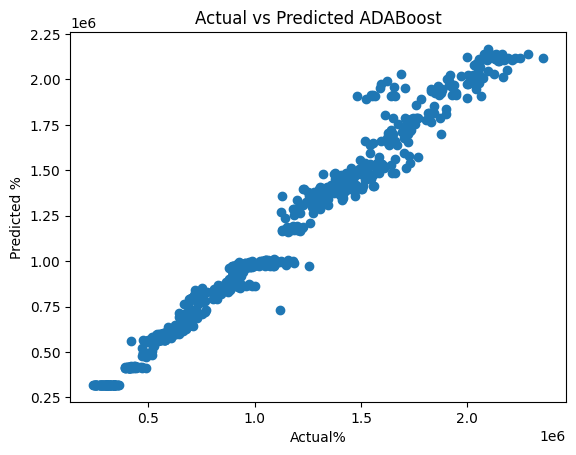

In [62]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted ADABoost")
plt.show()

## 5.5 Scaled Model Baselines — Linear Regression, SVR, Neural Networks
Functions defined for inverse transforming predictions back to dollar values, computing evaluation metrics, and plotting results.

In [63]:
def inverse_transform(y_pred_scaled):
    y_pred_log = sales_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    return np.expm1(y_pred_log)

def evaluate_metrics(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}\n")

def plot_predictions(name, y_test, y_pred):
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Weekly Sales ($)")
    plt.ylabel("Predicted Weekly Sales ($)")
    plt.title(name)
    plt.tight_layout()
    plt.show()

### 5.6 Train/Test Split — Scaled Models

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

split_idx = int(len(df_scaled) * 0.8)

X_scaled = df_scaled.drop(columns=['Weekly_Sales_scaled'])
y_scaled = df_scaled['Weekly_Sales_scaled']

X_scaled_train, X_scaled_test = X_scaled.iloc[:split_idx], X_scaled.iloc[split_idx:]
y_scaled_train, y_scaled_test = y_scaled.iloc[:split_idx], y_scaled.iloc[split_idx:]

# Compute actuals in dollars once
y_test_dollars = inverse_transform(y_scaled_test.values)

print(f"Train size: {len(X_scaled_train)} | Test size: {len(X_scaled_test)}")

Train size: 3276 | Test size: 819


### 5.7 Linear Regression Baseline

--- Multiple Linear Regression (Baseline) ---
  MAE  : 54,085.60
  RMSE : 79,534.69
  R²   : 0.9775



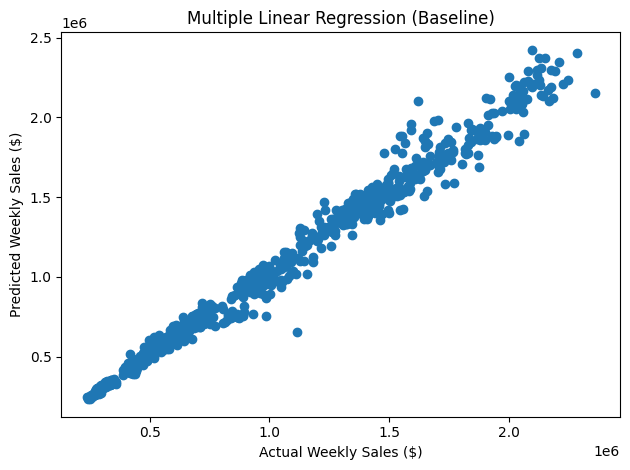

In [65]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_scaled_train, y_scaled_train)
y_pred_lr = inverse_transform(lr_model.predict(X_scaled_test))

evaluate_metrics("Multiple Linear Regression (Baseline)", y_test_dollars, y_pred_lr)
plot_predictions("Multiple Linear Regression (Baseline)", y_test_dollars, y_pred_lr)


### 5.8 SVR Baseline

--- SVR - RBF Kernel (Baseline) ---
  MAE  : 138,473.75
  RMSE : 186,185.40
  R²   : 0.8766



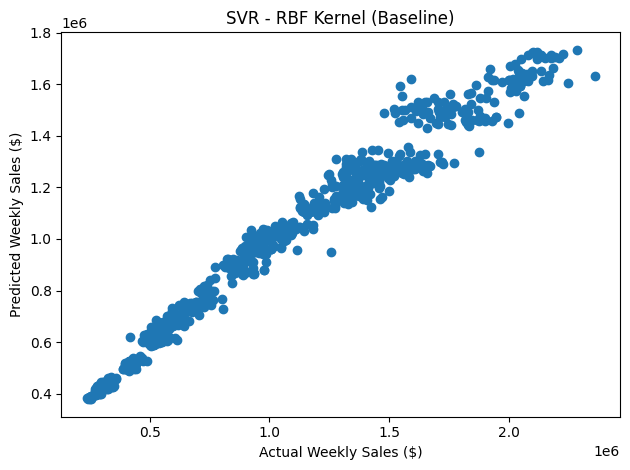

In [66]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_scaled_train, y_scaled_train)
y_pred_svr = inverse_transform(svr_model.predict(X_scaled_test))

evaluate_metrics("SVR - RBF Kernel (Baseline)", y_test_dollars, y_pred_svr)
plot_predictions("SVR - RBF Kernel (Baseline)", y_test_dollars, y_pred_svr)

### 5.9 Neural Network Baseline

--- Neural Network - MLP (Baseline) ---
  MAE  : 50,147.56
  RMSE : 73,598.06
  R²   : 0.9807



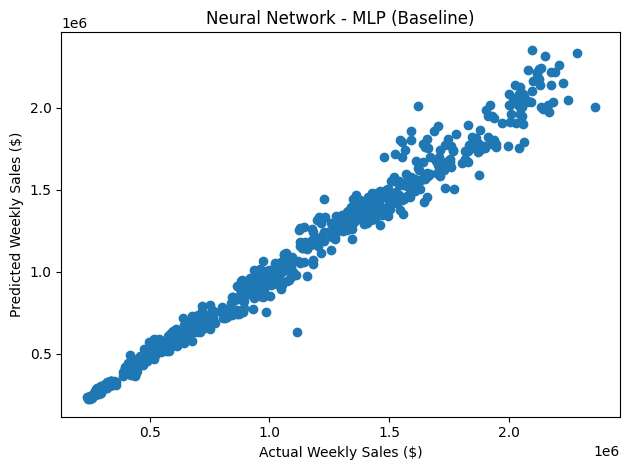

In [67]:
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2-layer baseline architecture
    activation='relu',
    max_iter=500,
    random_state=42
)
nn_model.fit(X_scaled_train, y_scaled_train)
y_pred_nn = inverse_transform(nn_model.predict(X_scaled_test))

evaluate_metrics("Neural Network - MLP (Baseline)", y_test_dollars, y_pred_nn)
plot_predictions("Neural Network - MLP (Baseline)", y_test_dollars, y_pred_nn)


### 5.10 Baseline Comparison Table
All seven baseline models ranked by R².

In [68]:
# Baseline Comparison Table

baseline_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVR',
        'Neural Network (MLP)',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'ADABoost'
    ],
    'MAE ($)': [
        mean_absolute_error(y_test_dollars, y_pred_lr),
        mean_absolute_error(y_test_dollars, y_pred_svr),
        mean_absolute_error(y_test_dollars, y_pred_nn),
        rf_mae,
        xgb_mae,
        lgb_mae,
        ada_mae
    ],
    'RMSE ($)': [
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_nn)),
        rf_rmse,
        xgb_rmse,
        lgb_rmse,
        ada_rmse
    ],
    'R²': [
        r2_score(y_test_dollars, y_pred_lr),
        r2_score(y_test_dollars, y_pred_svr),
        r2_score(y_test_dollars, y_pred_nn),
        rf_r2,
        xgb_r2,
        lgb_r2,
        ada_r2
    ]
})

baseline_results = baseline_results.sort_values('R²', ascending=False).reset_index(drop=True)
baseline_results['MAE ($)'] = baseline_results['MAE ($)'].map('{:,.2f}'.format)
baseline_results['RMSE ($)'] = baseline_results['RMSE ($)'].map('{:,.2f}'.format)
baseline_results['R²'] = baseline_results['R²'].map('{:.4f}'.format)

baseline_results = baseline_results.sort_values('R²', ascending=False).reset_index(drop=True)
baseline_results

,Model,MAE ($),RMSE ($),R²
0,Random Forest,"40,686.13","59,375.15",0.9875
1,LightGBM,"40,352.21","61,188.70",0.9867
2,XGBoost,"42,010.77","66,226.25",0.9844
3,Neural Network (MLP),"50,147.56","73,598.06",0.9807
4,ADABoost,"48,728.17","74,640.82",0.9802
5,Linear Regression,"54,085.60","79,534.69",0.9775
6,SVR,"138,473.75","186,185.40",0.8766


## 6. Hyperparameter Tuning
Optuna is used to tune the three best-performing tree models using 5-fold cross validation. Each study runs 20 trials, optimising for minimum RMSE.

In [69]:
!pip install Optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.2 MB/s eta 0:00:00


### 6.1 Random Forest — Tuned

In [70]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 10, 100),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_estimators': 692, 'max_depth': 54, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best CV RMSE: 102500.0811


--- Random Forest (Tuned) ---
  MAE  : 40,775.04
  RMSE : 59,273.00
  R²   : 0.9875



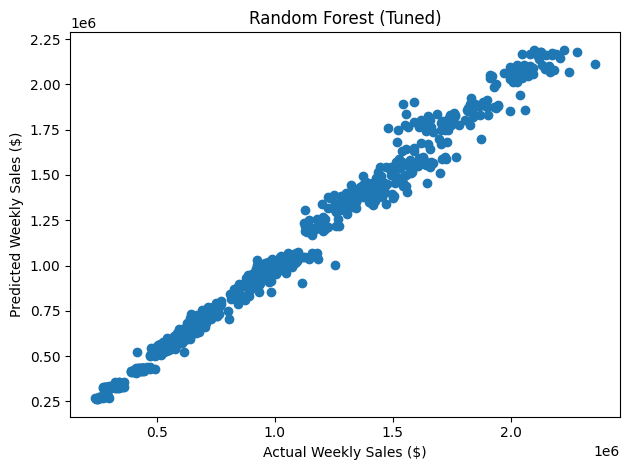

In [71]:
best_rf = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
y_pred_rf_tuned = best_rf.predict(X_test)

evaluate_metrics("Random Forest (Tuned)", y_test, y_pred_rf_tuned)
plot_predictions("Random Forest (Tuned)", y_test, y_pred_rf_tuned)

### 6.2 XGBoost — Tuned

In [72]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()


X_train['Holiday_Flag'] = X_train['Holiday_Flag'].astype(int)
X_test['Holiday_Flag'] = X_test['Holiday_Flag'].astype(int)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.4f}")

/tmp/ipykernel_8583/656981633.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Holiday_Flag'] = X_train['Holiday_Flag'].astype(int)
/tmp/ipykernel_8583/656981633.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Holiday_Flag'] = X_test['Holiday_Flag'].astype(int)


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_estimators': 215, 'max_depth': 4, 'learning_rate': 0.02077531386828824, 'subsample': 0.9085300540654999, 'colsample_bytree': 0.9865088879258762}
Best CV RMSE: 90176.5254


--- XGBoost (Tuned) ---
  MAE  : 40,764.28
  RMSE : 64,980.94
  R²   : 0.9850



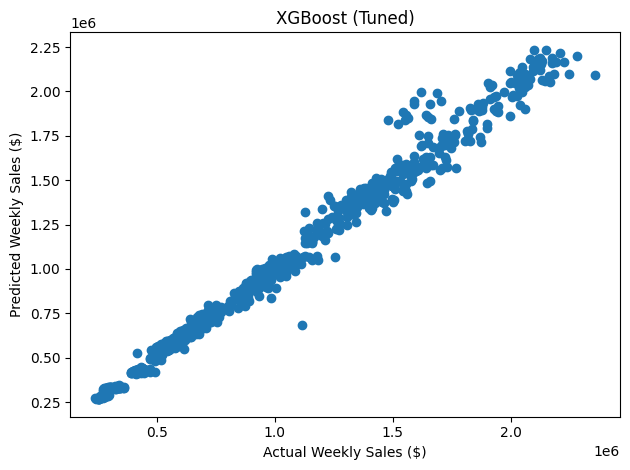

In [73]:
best_xgb = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_xgb.fit(X_train, y_train)
y_pred_xgb_tuned = best_xgb.predict(X_test)

evaluate_metrics("XGBoost (Tuned)", y_test, y_pred_xgb_tuned)
plot_predictions("XGBoost (Tuned)", y_test, y_pred_xgb_tuned)

### 6.3 LightGBM — Tuned

In [74]:
from lightgbm import LGBMRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 60),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_estimators': 681, 'max_depth': 3, 'learning_rate': 0.006303305727418379, 'num_leaves': 92, 'feature_fraction': 0.7890285656363937, 'bagging_fraction': 0.9948183244576232, 'bagging_freq': 4, 'min_data_in_leaf': 11}
Best CV RMSE: 95801.3339


--- LightGBM (Tuned) ---
  MAE  : 40,497.03
  RMSE : 64,467.34
  R²   : 0.9852



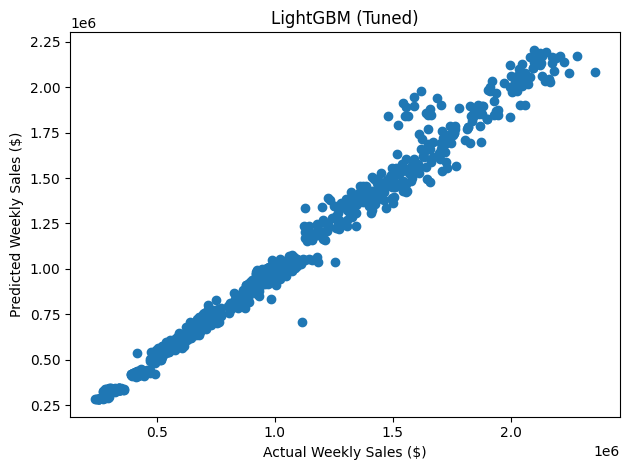

In [75]:
best_lgb = LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
best_lgb.fit(X_train, y_train)
y_pred_lgb_tuned = best_lgb.predict(X_test)

evaluate_metrics("LightGBM (Tuned)", y_test, y_pred_lgb_tuned)
plot_predictions("LightGBM (Tuned)", y_test, y_pred_lgb_tuned)

### 6.4 Full Model Comparison Table
All baseline and tuned models ranked by R².

In [78]:
comparison_results = pd.DataFrame({
    'Model': [
        'Linear Regression (Baseline)',
        'SVR (Baseline)',
        'Neural Network (Baseline)',
        'Random Forest (Baseline)',
        'XGBoost (Baseline)',
        'LightGBM (Baseline)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)',
        'LightGBM (Tuned)',
        'AdaBoost (Baseline)',
    ],
    'MAE ($)': [
        mean_absolute_error(y_test_dollars, y_pred_lr),
        mean_absolute_error(y_test_dollars, y_pred_svr),
        mean_absolute_error(y_test_dollars, y_pred_nn),
        rf_mae, xgb_mae, lgb_mae,
        mean_absolute_error(y_test, y_pred_rf_tuned),
        mean_absolute_error(y_test, y_pred_xgb_tuned),
        mean_absolute_error(y_test, y_pred_lgb_tuned),
        ada_mae,
    ],
    'RMSE ($)': [
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_nn)),
        rf_rmse, xgb_rmse, lgb_rmse,
        np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgb_tuned)),
        ada_rmse,
    ],
    'R²': [
        r2_score(y_test_dollars, y_pred_lr),
        r2_score(y_test_dollars, y_pred_svr),
        r2_score(y_test_dollars, y_pred_nn),
        rf_r2, xgb_r2, lgb_r2,
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_xgb_tuned),
        r2_score(y_test, y_pred_lgb_tuned),
        ada_r2,
    ]
})

comparison_results = comparison_results.sort_values('R²', ascending=False).reset_index(drop=True)

comparison_results

,Model,MAE ($),RMSE ($),R²
0,Random Forest (Tuned),40775.036128,59273.001284,0.987496
1,Random Forest (Baseline),40686.129256,59375.148458,0.987453
2,LightGBM (Baseline),40352.208418,61188.700265,0.986675
3,LightGBM (Tuned),40497.032493,64467.338448,0.985209
4,XGBoost (Tuned),40764.276422,64980.940604,0.984972
5,XGBoost (Baseline),42010.771327,66226.251473,0.984391
6,Neural Network (Baseline),50147.555657,73598.059608,0.980722
7,AdaBoost (Baseline),48728.169673,74640.815533,0.980172
8,Linear Regression (Baseline),54085.600441,79534.692617,0.977487
9,SVR (Baseline),138473.746888,186185.397204,0.876628


### 6.5 Baseline vs Tuned Comparison Chart
Visual comparison of R² improvement after tuning for the three tree-based models

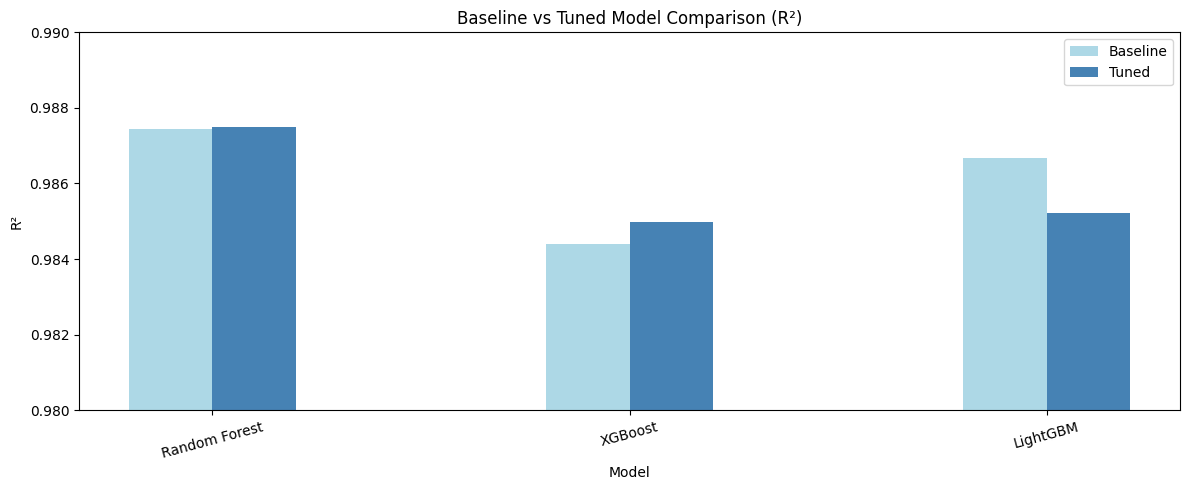

In [83]:
models = ['Random Forest', 'XGBoost', 'LightGBM']

baseline_r2  = [
    rf_r2, xgb_r2, lgb_r2
]

tuned_r2 = [
    r2_score(y_test, y_pred_rf_tuned),
    r2_score(y_test, y_pred_xgb_tuned),
    r2_score(y_test, y_pred_lgb_tuned),
]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, baseline_r2, width, label='Baseline', color='lightblue')
bars2 = ax.bar(x + width/2, [v if v is not None else 0 for v in tuned_r2], width, label='Tuned', color='steelblue')

ax.set_xlabel('Model')
ax.set_ylabel('R²')
ax.set_title('Baseline vs Tuned Model Comparison (R²)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0.98, .99)

plt.tight_layout()
plt.show()

## 7. Feature Importance
Permutation importance measures the drop in R² when each feature is randomly shuffled. A larger drop indicates the model relied more heavily on that feature.

In [86]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False).reset_index(drop=True)

perm_imp_df

,Feature,Importance,Std
0,Sales_Lag_52,1.148384e-01,0.002357
1,Sales_Rolling_4,6.364003e-02,0.001626
2,Store_Mean_Sales,6.338694e-02,0.001761
3,Sales_Lag_1,4.500585e-02,0.001307
4,Sales_Lag_4,2.202591e-02,0.000715
5,Store_4,1.978034e-03,0.000344
6,Store_20,1.949443e-03,0.000351
7,Store_13,1.362406e-03,0.000292
8,Unemployment,1.105021e-03,0.000228
9,Store_10,7.014780e-04,0.000117


### 7.1 Permutation Importance Chart — Top 15 Features

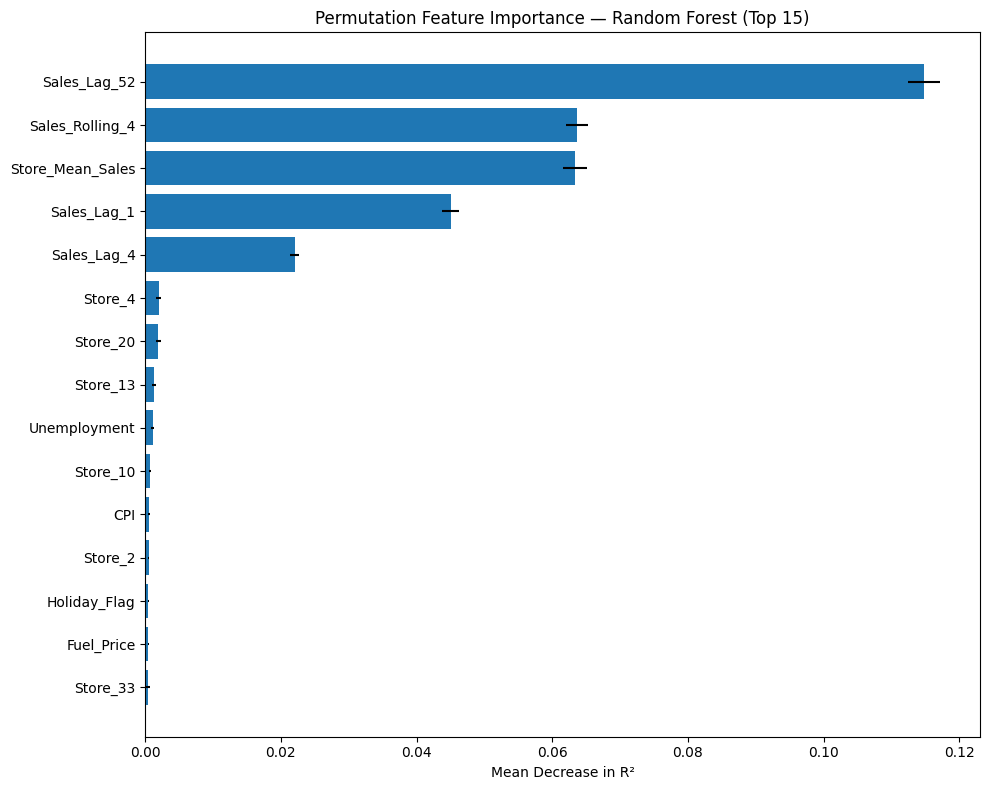

In [87]:
plt.figure(figsize=(10, 8))
plt.barh(
    perm_imp_df['Feature'][:15],
    perm_imp_df['Importance'][:15],
    xerr=perm_imp_df['Std'][:15],
    align='center'
)
plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in R²')
plt.title('Permutation Feature Importance — Random Forest (Top 15)')
plt.tight_layout()
plt.show()